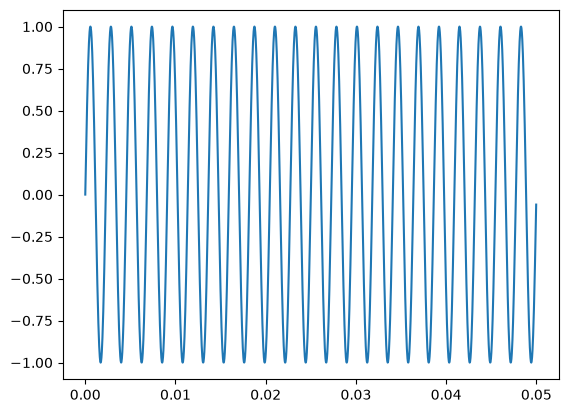

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile

RATE = 44_100
LA = 440
DO = 523.25

T = np.linspace(0,1,RATE)
son = np.sin(2*np.pi*LA*T)

plt.plot(T[:(44100//20)],son[:(44100//20)])
plt.show()

audio = Audio(son, rate=RATE)
display(audio)



In [2]:
def display_signal(signal) :
    display(Audio(signal, rate=RATE))

In [3]:
def sine(freq, duration=1, amplitude=1) :
    t = np.linspace(0,duration,RATE*duration) 
    return amplitude*np.sin(2*np.pi*freq*t)


In [4]:
def sine_linear(freq1,freq2,duration) :
    t = np.linspace(0,duration,RATE*duration)
    f = (freq1 + (freq2-freq1)*t/duration)
    return np.sin(2*np.pi*f*t)

In [5]:
display_signal(sine_linear(LA,DO,2))
display_signal(sine_linear(DO,LA,2))

In [6]:
def crescendo_sine(freq,duration,increase) :
    t = np.linspace(0,duration,RATE*duration) 
    if(increase) :
        return (t/duration)*np.sin(2*np.pi*freq*t)
    return (1-t/duration)*np.sin(2*np.pi*freq*t)

In [7]:
display_signal(crescendo_sine(LA,2,True))
display_signal(crescendo_sine(LA,2,False))

In [8]:
def crescendo(signal, increase) :
    duration = len(signal)//RATE
    t = np.linspace(0,duration,RATE*duration) 
    if(increase) :
        return (t/duration)*signal
    return (1-t/duration)*signal

In [9]:
display_signal(crescendo(sine_linear(LA,DO,2),True))

In [ ]:
display_signal(np.concatenate((sine(LA),sine(DO))))

In [11]:
def float_to_int16(as_float) :
    tab = 32767*as_float
    return tab.astype(np.int16)

In [12]:
float_to_int16(np.sin(np.linspace(0,10,100)))

array([     0,   3304,   6574,   9778,  12881,  15854,  18665,  21285,
        23689,  25851,  27749,  29365,  30681,  31685,  32365,  32716,
        32733,  32416,  31769,  30798,  29513,  27927,  26056,  23920,
        21540,  18941,  16148,  13190,  10099,   6904,   3639,    336,
        -2968,  -6244,  -9456, -12571, -15558, -18387, -21028, -23455,
       -25643, -27569, -29214, -30561, -31597, -32311, -32695, -32746,
       -32464, -31850, -30911, -29658, -28102, -26259, -24149, -21793,
       -19214, -16440, -13498, -10418,  -7233,  -3973,   -673,   2633,
         5913,   9133,  12259,  15261,  18107,  20769,  23218,  25432,
        27385,  29060,  30438,  31506,  32253,  32671,  32756,  32507,
        31927,  31021,  29799,  28273,  26459,  24376,  22043,  19486,
        16731,  13804,  10737,   7561,   4307,   1010,  -2297,  -5581,
        -8809, -11946, -14962, -17825], dtype=int16)

In [13]:
entiers = np.arange(0,13,1)
alpha = 2**(1/12)
ratios = np.power(alpha,entiers)
print(ratios)

[1.         1.05946309 1.12246205 1.18920712 1.25992105 1.33483985
 1.41421356 1.49830708 1.58740105 1.68179283 1.78179744 1.88774863
 2.        ]


In [14]:
d = {}
d['do'] = 0
d['do#'] = 1
d['ré'] = 2
d['ré#'] = 3
d['mi'] = 4
d['fa'] = 5
d['fa#'] = 6
d['sol'] = 7
d['sol#'] = 8
d['la'] = 9
d['la#'] = 10
d['si'] = 11


def freq_from_name(name) :
    return 440*(2**(1/12))**(d[name]-d['la'])

In [15]:
freq_from_name('la') == 440

True

In [25]:
wavfile.write('sample.wav',RATE,float_to_int16(np.concatenate((sine(LA),sine(DO)))))

In [26]:
restored = wavfile.read('sample.wav')
display_signal(restored[1])

In [32]:
data = wavfile.read('media/sounds-cello.wav')
display_signal(data[1])

In [35]:
samplerate = data[0]
print(samplerate)

44100


In [36]:
nb_echantillons = len(data[1])
print(nb_echantillons)

405891


In [37]:
duration = nb_echantillons/samplerate
print(duration)

9.203877551020408


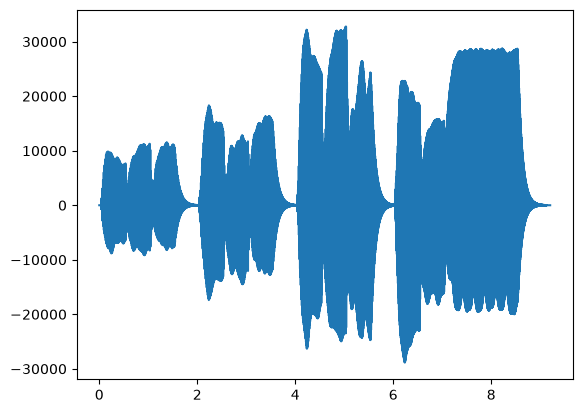

In [39]:
t = np.linspace(0,duration,nb_echantillons)
plt.plot(t,data[1])
plt.show()

In [41]:
delay = 2  # en secondes
main_ratio, delayed_ratio = 0.7, 0.3
offset = delay*RATE